In [53]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

import eurostat #python wrapper for taking data. 
import time

In [54]:
# Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals' #Gio
Share_point = r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals' #Ugne

In [55]:
import os
os.chdir(Share_point)

In [56]:
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\LNG terminals'

In [57]:
#Points_APIs = pd.read_excel(r'Dataproviders 31.10.2023.xlsx',sheet_name='LNG terminals') # good practice would be to update the Dataproviders file every few months
Points_APIs = pd.read_excel(r'Dataproviders 31.07.2024.xlsx',sheet_name='LNG terminals') # good practice would be to update the Dataproviders file every few months

In [58]:
Points_APIs.head()

,Country,Type,EIC Code,URL,Short Name,Name
0,BE,LNG Terminal,21W0000000001245,https://alsi.gie.eu/api?country=BE&company=21X...,NaN,Zeebrugge LNG Terminal
1,HR,LNG Terminal,31W-0000-G-000-Z,https://alsi.gie.eu/api?country=HR&company=31X...,NaN,Krk LNG Terminal (FSRU LNG CROATIA)
2,FI,LNG Terminal,21W000000000130A,https://alsi.gie.eu/api?country=FI&company=66X...,NaN,Inkoo LNG Terminal (FSRU Exemplar)
3,FI,LNG Terminal,66W000000000001U,https://alsi.gie.eu/api?country=FI&company=66X...,NaN,Hamina LNG Terminal
4,FR,LNG Terminal,63W179356656691A,https://alsi.gie.eu/api?country=FR&company=21X...,NaN,Fos Tonkin LNG Terminal


### key for version 6 and 7 of the API calls GIE

In [59]:
headers = {"x-key":"d8561648296cb38e6c400823755689941530"} # After July 4th 2022
# ideally each user should have its own API key

### Restart here

In [60]:
d1 = '2024-07-01'
d2 = '2024-12-31' # To change in the new year

In [61]:
Points_APIs.head()

,Country,Type,EIC Code,URL,Short Name,Name
0,BE,LNG Terminal,21W0000000001245,https://alsi.gie.eu/api?country=BE&company=21X...,NaN,Zeebrugge LNG Terminal
1,HR,LNG Terminal,31W-0000-G-000-Z,https://alsi.gie.eu/api?country=HR&company=31X...,NaN,Krk LNG Terminal (FSRU LNG CROATIA)
2,FI,LNG Terminal,21W000000000130A,https://alsi.gie.eu/api?country=FI&company=66X...,NaN,Inkoo LNG Terminal (FSRU Exemplar)
3,FI,LNG Terminal,66W000000000001U,https://alsi.gie.eu/api?country=FI&company=66X...,NaN,Hamina LNG Terminal
4,FR,LNG Terminal,63W179356656691A,https://alsi.gie.eu/api?country=FR&company=21X...,NaN,Fos Tonkin LNG Terminal


In [62]:
#Points_APIs['URL'][0]

In [63]:
import json  # Ensure you import the json module

dates = []
sendOut = []
stored = []
max_storage = []
max_sendout = []
country = []
Name = []

for item in range(len(Points_APIs)):
    url = Points_APIs.iloc[item, 3] + '&from={}&to={}&size=300'.format(d1, d2)
    try:
        r = requests.get(url, headers=headers)
        if r.status_code != 200:
            print(r.status_code)
            print(url)

        raw_data = r.json()
        inner_data = raw_data['data']
        for x in inner_data:
            # here we work with the APIs
            date = x['gasDayStart']

            # Process 'inventory' to extract the last value
            inventory_data = x['inventory']
            if isinstance(inventory_data, str):  # Convert string to dict if necessary
                inventory_data = json.loads(inventory_data)
            if isinstance(inventory_data, dict):  # Extract the last value from the dict
                inventory_values = list(inventory_data.values())
                inventory = float(inventory_values[-1]) if inventory_values else None

            sendOuts = x['sendOut']

            # Process 'Max_Storage' to extract the last value
            Max_Storage_data = x['dtmi']
            if isinstance(Max_Storage_data, str):  # Convert string to dict if necessary
                Max_Storage_data = json.loads(Max_Storage_data)
            if isinstance(Max_Storage_data, dict):  # Extract the last value from the dict
                Max_Storage_values = list(Max_Storage_data.values())
                Max_Storage = float(Max_Storage_values[-1]) if Max_Storage_values else None

            Max_Sendout = x['dtrs']

            # here we work with the excel file
            countries = Points_APIs.iloc[item, 0]
            Names = Points_APIs.iloc[item, 5]

            dates.append(date)
            sendOut.append(sendOuts)
            stored.append(inventory)  # Append the last value of 'inventory'
            max_storage.append(Max_Storage)  # Append the last value of 'Max_Storage'
            max_sendout.append(Max_Sendout)
            country.append(countries)
            Name.append(Names)
    except Exception as e:
        print(e)


could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'
could not convert string to float: '-'


In [64]:
import json  # Ensure you import the json module
import requests  # Ensure you import the requests module

dates = []
sendOut = []
stored = []
max_storage = []
max_sendout = []
country = []
Name = []

for item in range(len(Points_APIs)):
    url = Points_APIs.iloc[item, 3] + '&from={}&to={}&size=300'.format(d1, d2)
    try:
        r = requests.get(url, headers=headers)
        if r.status_code != 200:
            print(r.status_code)
            print(url)
            continue

        raw_data = r.json()
        inner_data = raw_data['data']
        for x in inner_data:
            # here we work with the APIs
            date = x['gasDayStart']

            # Process 'inventory' to extract the last value
            inventory_data = x['inventory']
            if isinstance(inventory_data, str):  # Convert string to dict if necessary
                try:
                    inventory_data = json.loads(inventory_data)
                except json.JSONDecodeError as json_err:
                    print(f"Error decoding inventory data: {json_err}, data: {inventory_data}")
                    continue
            if isinstance(inventory_data, dict):  # Extract the last value from the dict
                inventory_values = list(inventory_data.values())
                if inventory_values and inventory_values[-1] != '-':
                    try:
                        inventory = float(inventory_values[-1])
                    except ValueError as ve:
                        print(f"Error converting inventory to float: {ve}, data: {inventory_values[-1]}")
                        continue
                else:
                    inventory = None  # or some default value

            sendOuts = x['sendOut']

            # Process 'Max_Storage' to extract the last value
            Max_Storage_data = x['dtmi']
            if isinstance(Max_Storage_data, str):  # Convert string to dict if necessary
                try:
                    Max_Storage_data = json.loads(Max_Storage_data)
                except json.JSONDecodeError as json_err:
                    print(f"Error decoding Max_Storage data: {json_err}, data: {Max_Storage_data}")
                    continue
            if isinstance(Max_Storage_data, dict):  # Extract the last value from the dict
                Max_Storage_values = list(Max_Storage_data.values())
                if Max_Storage_values and Max_Storage_values[-1] != '-':
                    try:
                        Max_Storage = float(Max_Storage_values[-1])
                    except ValueError as ve:
                        print(f"Error converting Max_Storage to float: {ve}, data: {Max_Storage_values[-1]}")
                        continue
                else:
                    Max_Storage = None  # or some default value

            Max_Sendout = x['dtrs']

            # here we work with the excel file
            countries = Points_APIs.iloc[item, 0]
            Names = Points_APIs.iloc[item, 5]

            dates.append(date)
            sendOut.append(sendOuts)
            stored.append(inventory)  # Append the last value of 'inventory'
            max_storage.append(Max_Storage)  # Append the last value of 'Max_Storage'
            max_sendout.append(Max_Sendout)
            country.append(countries)
            Name.append(Names)
    except Exception as e:
        print(f"Error processing URL {url}: {e}")


In [65]:
# inventory

In [66]:
df = pd.DataFrame()
df['dates'] = dates
df['sendOut'] = sendOut          ## in GWh/d
df['stored'] = stored            ## in 10^3 m^3 LNG
df['Max Storage'] = max_storage  ## in 10^3 m^3 LNG
df['Max Sendout'] = max_sendout  ## in GWh/d
df['country'] = country
df['name'] = Name

In [67]:
# Getting rid of NaNa
df.replace('-', np.NaN,inplace=True)
# Getting rid of observations for which we have no data
# df = df.dropna()

In [68]:
# trasfom all the numerical observation into numbers
df['sendOut'] = pd.to_numeric(df['sendOut'])
df['stored'] = pd.to_numeric(df['stored'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 
df['Max Sendout'] = pd.to_numeric(df['Max Sendout']) 

In [69]:
df.shape

(7176, 7)

In [70]:
from datetime import date
df.to_csv('raw_data/2024_2.csv')

###  merge with historic data

In [71]:
# Change current directory
import os
os.chdir(Share_point + '\\raw_data')

In [72]:
df_1 = pd.read_csv('2015.csv',index_col=0)
df_2 = pd.read_csv('2016.csv',index_col=0)
df_3 = pd.read_csv('2017.csv',index_col=0)
df_4 = pd.read_csv('2018.csv',index_col=0)
df_5a = pd.read_csv('2019_1.csv',index_col=0)
df_5b = pd.read_csv('2019_2.csv',index_col=0)
df_6a = pd.read_csv('2020_1.csv',index_col=0)
df_6b = pd.read_csv('2020_2.csv',index_col=0)
df_7a = pd.read_csv('2021_1.csv',index_col=0)
df_7b = pd.read_csv('2021_2.csv',index_col=0)
df_8a = pd.read_csv('2022_1.csv',index_col=0)
df_8b = pd.read_csv('2022_2.csv',index_col=0)
df_9a = pd.read_csv('2023_1.csv',index_col=0)
df_9b = pd.read_csv('2023_2.csv',index_col=0)
df_10a = pd.read_csv('2024_1.csv',index_col=0)
df_10b = pd.read_csv('2024_2.csv',index_col=0)

In [73]:
df = pd.concat([df_1,df_2,df_3,df_4,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a,df_9b,df_10a, df_10b])

In [74]:
# del df['Unnamed: 0'] #need to run only when importing the data (not downloading from online)
# drops duplicates
df = df.drop_duplicates()

In [75]:
from datetime import date
today = date.today()
# this is used to have Sunday's observation as last ones when running on Wednesday (most recent data often partially missing)
last_obs = today - timedelta(days=2)  # you want it equal to 2 on Tuesday and 3 on Wednesday

In [76]:
df

,dates,sendOut,stored,Max Storage,Max Sendout,country,name
0,2015-12-31,22.0,198.51,374.0,444.5,BE,Zeebrugge LNG Terminal
1,2015-12-30,20.6,201.42,374.0,444.5,BE,Zeebrugge LNG Terminal
2,2015-12-29,22.3,204.87,374.0,444.5,BE,Zeebrugge LNG Terminal
3,2015-12-28,22.1,208.28,374.0,444.5,BE,Zeebrugge LNG Terminal
4,2015-12-27,22.5,211.71,374.0,444.5,BE,Zeebrugge LNG Terminal
...,...,...,...,...,...,...,...
7171,2024-07-05,NaN,NaN,NaN,NaN,GB*,South Hook LNG Terminal (Post-Brexit)
7172,2024-07-04,NaN,NaN,NaN,NaN,GB*,South Hook LNG Terminal (Post-Brexit)
7173,2024-07-03,NaN,NaN,NaN,NaN,GB*,South Hook LNG Terminal (Post-Brexit)
7174,2024-07-02,NaN,NaN,NaN,NaN,GB*,South Hook LNG Terminal (Post-Brexit)


In [77]:
df = df.set_index(pd.DatetimeIndex(df['dates']))
del df['dates']
df = df.sort_values(by='dates')

In [78]:
# check countries
df.country.unique()

array(['ES', 'IT', 'FR', 'NL', 'PT', 'GR', 'BE', 'GB', 'LT', 'PL', 'ES*',
       'GB*', 'HR', 'DE', 'FI'], dtype=object)

In [79]:
# Change current directory
import os
os.chdir(Share_point)

In [80]:
# group by date and country (for countries with multiple terminals)
df_C = df.groupby(['dates','country']).sum().reset_index()
df_C = df_C.set_index(pd.DatetimeIndex(df_C['dates']))

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_28144\4144074994.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_C = df.groupby(['dates','country']).sum().reset_index()


## regassification % - Weekly data

In [81]:
# Here we are interested in getting the LNG regassification in % of total capacity

In [82]:
from datetime import date
today = date.today()
last_obs = today - timedelta(days=2) # can be also -3
print(last_obs)
# enddate = datetime.strptime('2022-07-17', "%d-%m-%Y") this useful only if done manually
enddate = last_obs
startdate = enddate - timedelta(days=30)  # to be removed?

2024-12-31


In [83]:
df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()
df_w=df_w.set_index(pd.DatetimeIndex(df_w['dates']))

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_28144\3929813282.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_w = df_C.groupby([pd.Grouper(freq='W'),'country']).sum().reset_index()


In [84]:
# check countries
df_w.country.unique()

array(['BE', 'ES', 'FR', 'GB', 'GR', 'IT', 'NL', 'PT', 'LT', 'PL', 'ES*',
       'GB*', 'HR', 'DE', 'FI'], dtype=object)

In [85]:
df_w = df_w[~df_w.country.isin(['ES*','GB','GB*'])] # Get rid of UK and ES TVB aggregate --> for which there is no data pre-2020

In [86]:
del df_w['dates']

In [87]:
## Can change from new year
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

# plot = df_w.groupby([pd.Grouper(freq='W'),'country']).sum()[:] ## use a converter if you want to transform the data
df_w['week'] = df_w.index.isocalendar().week

hist = df_w['2019-01-05':'2022-01-02'].groupby(['country','week']).mean().reset_index()
values2021 = df_w.loc['2020-12-28':'2022-01-02'].groupby(['country','week']).max().reset_index()
values2022 = df_w.loc['2022-01-03':'2023-01-01'].groupby(['country','week']).max().reset_index()
values2023 = df_w.loc['2023-01-01':'2023-12-31'].groupby(['country','week']).max().reset_index()
values2024 = df_w.loc['2024-01-01':'2024-12-29'].groupby(['country','week']).max().reset_index()

In [88]:
hist['regas %'] = (hist['sendOut']/hist['Max Sendout'])*100
values2021['regas %'] = (values2021['sendOut']/values2021['Max Sendout'])*100
values2022['regas %'] = (values2022['sendOut']/values2022['Max Sendout'])*100
values2023['regas %'] = (values2023['sendOut']/values2023['Max Sendout'])*100
values2024['regas %'] = (values2024['sendOut']/values2024['Max Sendout'])*100

In [89]:
import os
#os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')
os.chdir(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Data\LNG')

In [90]:
# saves the data in excel
Excelwriter = pd.ExcelWriter(r"GIE ALSI LNG terminals\LNG_GIE_weekly_data {}.xlsx".format(today),engine="xlsxwriter")
hist.to_excel(Excelwriter, sheet_name="2019-2021", index=False)
values2021.to_excel(Excelwriter, sheet_name="2021", index=False)
values2022.to_excel(Excelwriter, sheet_name="2022", index=False)
values2023.to_excel(Excelwriter, sheet_name="2023", index=False)
values2024.to_excel(Excelwriter, sheet_name="2024", index=False)
Excelwriter.close()
Excelwriter.save()

C:\Users\ugne.keliauskaite\AppData\Local\Temp\ipykernel_28144\4275560501.py:9: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  Excelwriter.save()
c:\Users\ugne.keliauskaite\AppData\Local\anaconda3\Lib\site-packages\xlsxwriter\workbook.py:368: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


## LNG send outs - weekly (for the ENTSOG imports file)

In [91]:
cplot = df.loc[~df['country'].isin(['GB','GB*'])].reset_index() # getting rid of UK data 
cplot['dates'] = pd.to_datetime(cplot['dates'])  # Convert the date column to datetime

In [92]:
cplot.country.unique()

array(['ES', 'IT', 'FR', 'NL', 'PT', 'GR', 'BE', 'LT', 'PL', 'ES*', 'HR',
       'DE', 'FI'], dtype=object)

In [93]:
# to keep only TVB (Virtual balancing LNG tank) after July 2020
# TVB --> virtual balanging LNG for all country's terminals (country ES*)
# Filter the DataFrame to keep only specific names after July 2020
es_lng_points = ['Bilbao LNG Terminal', 'Cartagena LNG Terminal', 'Barcelona LNG Terminal', 'Mugardos LNG Terminal','Huelva LNG Terminal','Sagunto LNG Terminal']
date_threshold = pd.to_datetime('2020-07-09')
ccplot = cplot[~((cplot['name'].isin(es_lng_points)) & (cplot['dates'] >= date_threshold))]

In [94]:
# just a check that the above cell worked (can get rid of it). We want single terminals before 2020-07-09 and the TVB aggregate afterwards
ccplot[ccplot['country']=='ES']

,dates,sendOut,stored,Max Storage,Max Sendout,country,name
0,2015-03-07,113.9,281.25,617.89,375.8,ES,Huelva LNG Terminal
2,2015-03-07,35.9,190.15,585.48,375.8,ES,Cartagena LNG Terminal
3,2015-03-07,35.7,100.40,300.00,115.2,ES,Mugardos LNG Terminal
10,2015-03-07,88.3,75.66,448.83,222.7,ES,Bilbao LNG Terminal
11,2015-03-07,63.7,272.37,598.44,278.3,ES,Sagunto LNG Terminal
...,...,...,...,...,...,...,...
73110,2024-12-29,NaN,NaN,NaN,NaN,ES,El Musel LNG Terminal (Prior to 29/09/2023)
73124,2024-12-30,NaN,NaN,NaN,NaN,ES,El Musel LNG Terminal (Prior to 29/09/2023)
73130,2024-12-30,31.6,358.19,857.07,221.8,ES,El Musel LNG Terminal
73176,2024-12-31,31.6,358.19,857.07,221.8,ES,El Musel LNG Terminal


In [95]:
es = ccplot[(ccplot['country']=='ES*')].index
# now change the country to 'ES' also for balancing point TVB
for i in es:
    ccplot.loc[i,'country']='ES'

# reset index
ccplot = ccplot.reset_index()
ccplot=ccplot.set_index(pd.DatetimeIndex(ccplot['dates']))
del ccplot['dates']

In [96]:
# here we upload the LNG file on Sharepoint
#ccplot.to_csv(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals\raw_data\agsi.csv') # Gio
ccplot.to_csv(r'C:\Users\ugne.keliauskaite\Bruegel\Research - 2021-11 European natural gas imports\Code\LNG terminals\raw_data\agsi.csv') # Ugne 

In [97]:
# ------------------------------------------------------------------------------------------- can disregard from here (mostly checks) --------------------------------------------------------------------------------------------------------

In [51]:
cplot=cplot.set_index(pd.DatetimeIndex(cplot['dates']))

In [113]:
cplot_week = cplot.groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
cplot_week['week'] = cplot_week.index.isocalendar().week

In [114]:
cplot_week['M3m']=round(cplot_week['sendOut']/10.3,1)

In [115]:
cplot_week

,sendOut,stored,Max Storage,Max Sendout,week,M3m
dates,,,,,,
2015-03-08,1494.7,4822.92,12099.66,8974.8,10,145.1
2015-03-15,6573.9,15955.55,42348.81,31411.8,11,638.2
2015-03-22,8441.6,16134.85,42348.81,31411.8,12,819.6
2015-03-29,8573.1,15882.03,42348.81,31411.8,13,832.3
2015-04-05,7511.2,17142.37,41998.81,31155.3,14,729.2
...,...,...,...,...,...,...
2024-10-20,24712.7,314508.64,564551.41,68025.4,42,2399.3
2024-10-27,22983.3,348912.98,566269.23,67930.7,43,2231.4
2024-11-03,24662.2,335654.47,567886.32,67770.7,44,2394.4


<Axes: xlabel='dates'>

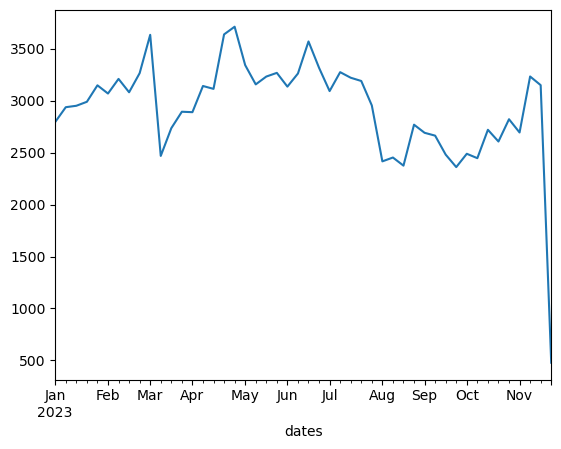

In [47]:
cplot_week['M3m']['2023':].plot()

## CHECKS: LNG send-outs  - Monthly

In [48]:
cplot = df.loc[~df['country'].str.startswith('GB')]

In [49]:
cplot_month =  cplot.groupby([pd.Grouper(freq='M'),'country']).sum(numeric_only=True).reset_index() #/converter

In [50]:
cplot_month['M3m'] = round(cplot_month['sendOut']/10.3,1)
print(cplot_month.tail())

         dates country  sendOut   stored  Max Storage  Max Sendout     M3m
951 2023-11-30      IT  10000.2  5273.73      12331.8      14313.4   970.9
952 2023-11-30      LT   1506.7  2050.66       3334.6       2364.3   146.3
953 2023-11-30      NL  12347.4  9554.41      13904.2      15364.0  1198.8
954 2023-11-30      PL   4028.6  2871.29       6400.0       4400.0   391.1
955 2023-11-30      PT   2219.3  6203.91       7800.0       4000.0   215.5


In [51]:
cmonth = pd.pivot_table(cplot_month,values='M3m',index='dates',columns='country')

In [52]:
cmonth= cmonth['2021-01':'2023-09']

In [53]:
cmonth.columns

Index(['BE', 'DE', 'ES', 'ES*', 'FR', 'GR', 'HR', 'IT', 'LT', 'NL', 'PL',
       'PT'],
      dtype='object', name='country')

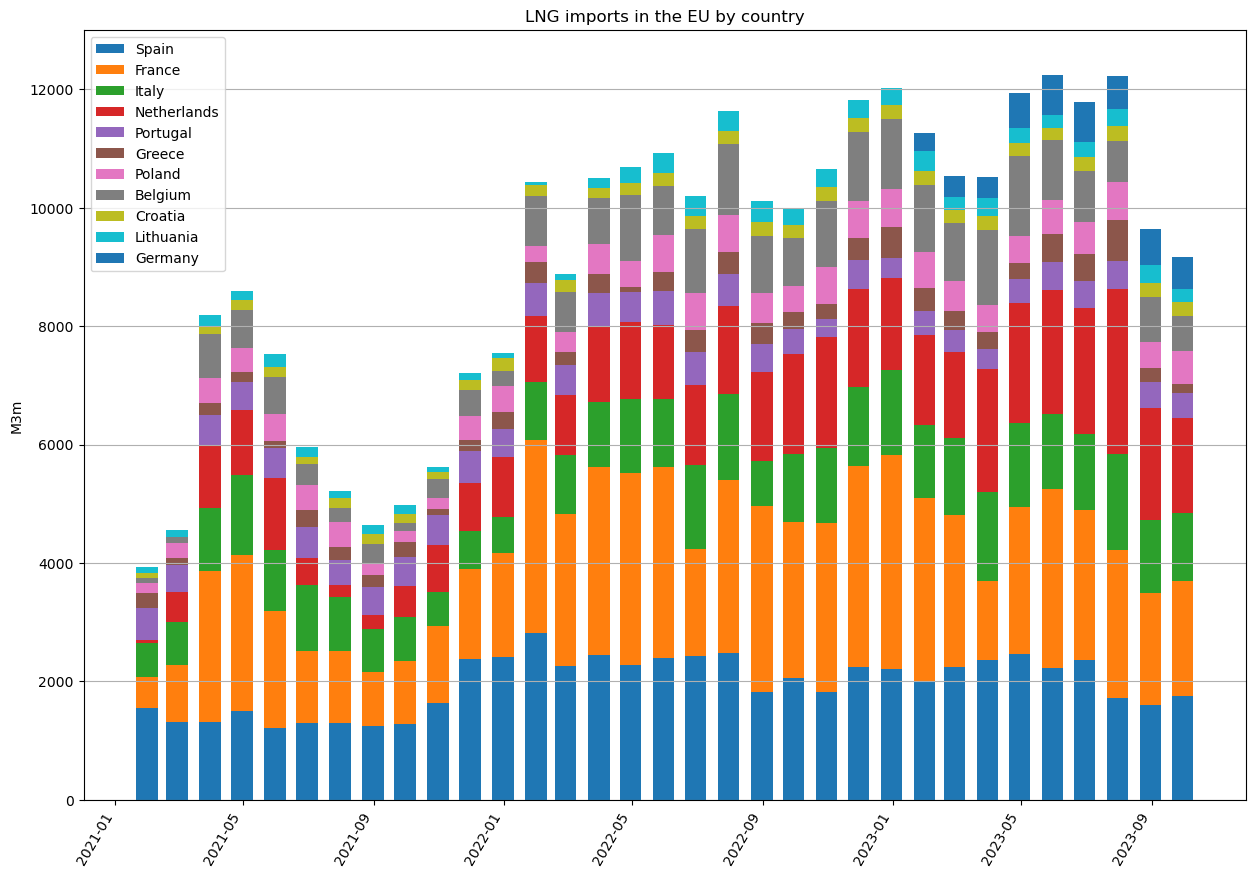

In [54]:
x = cmonth.index
width = 20       # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(15,10))

ax.bar(x, cmonth['ES*'], width, label='Spain')
ax.bar(x, cmonth['FR'], width, bottom=cmonth['ES*'],
       label='France')
ax.bar(x, cmonth['IT'], width, bottom=cmonth['ES*']+cmonth['FR'],
       label='Italy')
ax.bar(x, cmonth['NL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT'],
       label='Netherlands')
ax.bar(x, cmonth['PT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL'],
       label='Portugal')
ax.bar(x, cmonth['GR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT'],
       label='Greece')
ax.bar(x, cmonth['PL'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR'],
       label='Poland')
ax.bar(x, cmonth['BE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL'],
       label='Belgium')
ax.bar(x, cmonth['HR'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE'],
label='Croatia')
ax.bar(x, cmonth['LT'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR'],
label='Lithuania')
ax.bar(x, cmonth['DE'], width, bottom=cmonth['ES*']+cmonth['FR']+cmonth['IT']+cmonth['NL']+cmonth['PT']+cmonth['GR']+cmonth['PL']+cmonth['BE']+cmonth['HR']+cmonth['LT'],
label='Germany')
fig.set_facecolor('white')

plt.setp(ax.get_xticklabels(), rotation=60, horizontalalignment='right')

ax = plt.gca()
ax.set_ylim([0, 13000])
ax.grid(axis='y')

ax.set_ylabel('M3m')
ax.set_title('LNG imports in the EU by country')
ax.legend(loc='upper left')

plt.show()

Weekly

In [55]:
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

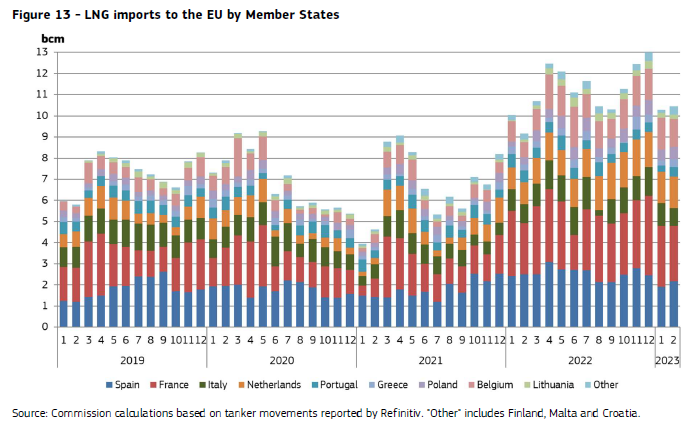

In [56]:
from IPython.display import Image, display
display(Image("Commission Qreport 2023.png",width=1200)) # to change after new Commission's gas report

#### checks for Spain

In [57]:
df[df['name']=='TVB (Virtual balancing LNG tank)']['sendOut']

dates
2020-07-09    790.9
2020-07-10    769.5
2020-07-11    677.7
2020-07-12    679.1
2020-07-13    729.5
              ...  
2023-11-16    757.4
2023-11-17    800.8
2023-11-18    565.6
2023-11-19    570.5
2023-11-20    658.9
Name: sendOut, Length: 1230, dtype: float64

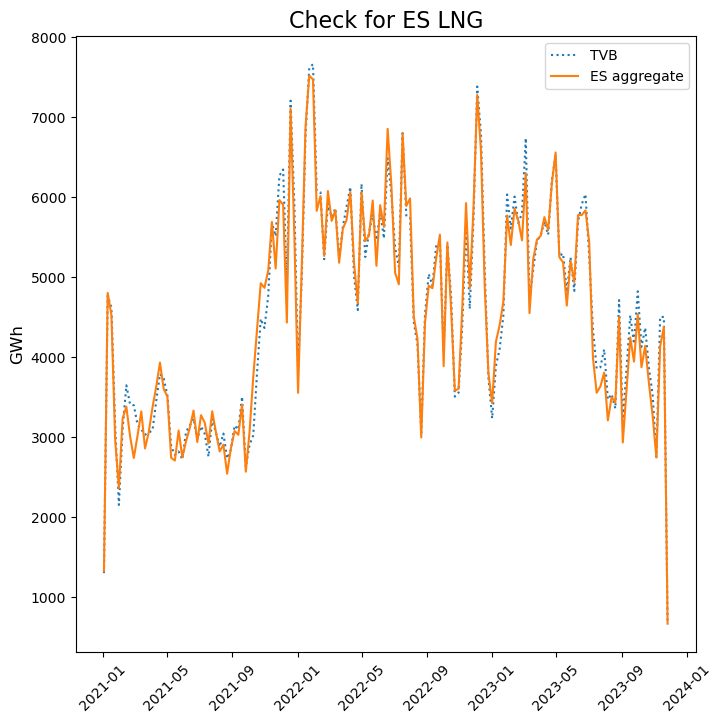

In [58]:
tvb = df[df['name']=='TVB (Virtual balancing LNG tank)']['2021':]
tvb_plot = tvb.groupby(pd.Grouper(freq='W'))['sendOut'].sum()
esp = df[df['country']=='ES']['2021':]
esp_plot = esp.groupby(pd.Grouper(freq='W'))['sendOut'].sum(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(tvb_plot,label='TVB',linestyle=':')
ax.plot(esp_plot,label='ES aggregate')

plt.xticks(rotation=45)
plt.title('Check for ES LNG',fontsize='16')
plt.ylabel('GWh',fontsize=12,loc='center')
plt.legend(loc='best')

In [59]:
import os
os.getcwd()

'C:\\Users\\ugne.keliauskaite\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\LNG'

In [60]:
df.country.unique()

array(['ES', 'IT', 'FR', 'NL', 'PT', 'GR', 'BE', 'GB', 'LT', 'PL', 'ES*',
       'GB*', 'HR', 'DE'], dtype=object)